In [2]:

import pandas as pd

df = pd.read_csv("/content/EPL_2526.csv")
df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,E0,25/04/2026,15:00,Liverpool,Crystal Palace,3,1,H,2,0,...,1.98,1.88,NaN,NaN,1.98,1.90,1.92,1.85,NaN,NaN
335,E0,25/04/2026,15:00,West Ham,Everton,2,1,H,0,0,...,1.78,2.10,NaN,NaN,1.78,2.10,1.75,2.04,NaN,NaN
336,E0,25/04/2026,15:00,Wolves,Tottenham,0,1,A,0,0,...,2.05,1.80,NaN,NaN,2.05,1.86,1.99,1.79,NaN,NaN
337,E0,25/04/2026,17:30,Arsenal,Newcastle,1,0,H,1,0,...,1.88,1.98,NaN,NaN,1.88,1.98,1.84,1.94,NaN,NaN


In [3]:
df = df.drop(df.columns[18:], axis=1)
df1=df.drop(columns=["FTR","HTHG","HTAG","HTR","Referee","Div","HF","AF"])
df1.rename(columns={"FTHG":"FullTimeHomeGoals","FTAG":"FullTimeAwayGoals","HS":"HomeShots","AS":"AwayShots","HST":"HomeShotsTarget","AST":"AwayShotsTarget"},inplace=True)
df1['Date'] = pd.to_datetime(df1['Date'])

/tmp/ipykernel_13284/565718114.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               339 non-null    datetime64[ns]
 1   Time               339 non-null    object        
 2   HomeTeam           339 non-null    object        
 3   AwayTeam           339 non-null    object        
 4   FullTimeHomeGoals  339 non-null    int64         
 5   FullTimeAwayGoals  339 non-null    int64         
 6   HomeShots          339 non-null    int64         
 7   AwayShots          339 non-null    int64         
 8   HomeShotsTarget    339 non-null    int64         
 9   AwayShotsTarget    339 non-null    int64         
dtypes: datetime64[ns](1), int64(6), object(3)
memory usage: 26.6+ KB


In [5]:
import numpy as np

df1["HomePoints"] = np.where(
        df1["FullTimeHomeGoals"] > df1["FullTimeAwayGoals"], 3,
        np.where(df1["FullTimeHomeGoals"] == df1["FullTimeAwayGoals"], 1, 0)
    )
df1["AwayPoints"] = np.where(
        df1["FullTimeAwayGoals"] > df1["FullTimeHomeGoals"], 3,
        np.where(df1["FullTimeHomeGoals"] == df1["FullTimeAwayGoals"], 1, 0)
    )

In [6]:
elo_ratings = {
    'Man City': 1746.13, 'Arsenal': 1735.61, 'Liverpool': 1698.76,
    'Brighton': 1604.03, 'Chelsea': 1598.76, 'Aston Villa': 1551.39,
    'Newcastle': 1548.76, 'Man United': 1535.61, 'Fulham': 1517.18,
    'Bournemouth': 1490.87, 'Crystal Palace': 1488.24, 'Tottenham': 1472.45,
    "Nott'm Forest": 1461.92, 'Brentford': 1440.87, 'Wolves': 1440.87,
    'Everton': 1425.08, 'West Ham': 1411.92, 'Sunderland': 1351.42,
    'Leeds': 1327.74, 'Burnley': 1276.58
}

In [7]:
# Assign Home and Away Elo based on the Team names
df1['HomeElo'] = df1['HomeTeam'].map(elo_ratings)
df1['AwayElo'] = df1['AwayTeam'].map(elo_ratings)

# Calculate the Elo Difference (Home - Away)
df1['Elo_Diff'] = df1['HomeElo'] - df1['AwayElo']

In [8]:
# Check if any teams didn't get a rating
missing_teams = df1[df1['HomeElo'].isna()]['HomeTeam'].unique()
print(f"Teams missing Elo: {missing_teams}")

Teams missing Elo: []


In [9]:
# 1. Calculate the Adjusted Elo Difference (including Home Advantage)
# We add 100 to the Home Team because they are playing at home
df1['Adjusted_Diff'] = (df1['HomeElo'] + 100) - df1['AwayElo']

# 2. Calculate Expected Win Probability for the Home Team
df1['Home_Win_Prob'] = 1 / (10**(-df1['Adjusted_Diff'] / 400) + 1)

# 3. Calculate Expected Win Probability for the Away Team
df1['Away_Win_Prob'] = 1 - df1['Home_Win_Prob']

In [10]:
def get_result(row):
    if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
        return 2 # Home Win
    elif row['FullTimeHomeGoals'] == row['FullTimeAwayGoals']:
        return 1 # Draw
    else:
        return 0 # Away Win

df1['Result'] = df1.apply(get_result, axis=1)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Create a combined list of all teams to ensure consistent numbering
all_teams = pd.concat([df1['HomeTeam'], df1['AwayTeam']]).unique()
le.fit(all_teams)

# Transform the names into numbers
df1['HomeTeam_ID'] = le.transform(df1['HomeTeam'])
df1['AwayTeam_ID'] = le.transform(df1['AwayTeam'])

In [12]:
# The 'X' (Inputs)
features = [
    'HomeTeam_ID', 'AwayTeam_ID',           # Identity
    'HomeElo', 'AwayElo',          # Raw Strength
    'Adjusted_Diff', 'Home_Win_Prob'     # Calculated Advantage
]

X = df1[features]
y = df1['Result'] # 0: Away Win, 1: Draw, 2: Home Win

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [15]:
model.score(X_test, y_test)

0.4852941176470588

In [16]:
from sklearn.metrics import accuracy_score, classification_report
y_predicted = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_predicted):.2f}")

Accuracy: 0.49


In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[ 8,  7,  9],
       [ 3,  6,  7],
       [ 4,  5, 19]])

Text(95.72222222222221, 0.5, 'Truth')

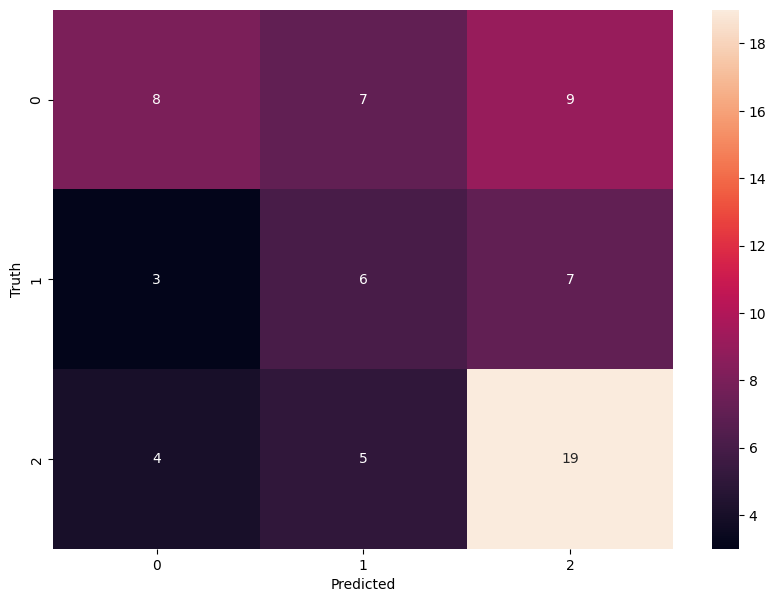

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [19]:
def predict_match(home_team, away_team, model, encoder, elo_dict):
    try:
        # 1. Get IDs
        h_id = encoder.transform([home_team])[0]
        a_id = encoder.transform([away_team])[0]

        # 2. Get Elos
        h_elo = elo_dict[home_team]
        a_elo = elo_dict[away_team]

        # 3. Calculate Features
        elo_diff = h_elo - a_elo
        # Apply the same 100-point home advantage used in training
        h_prob = 1 / (10**(-((h_elo + 100) - a_elo) / 400) + 1)

        # 4. Create DataFrame with EXACT column names from training
        input_data = pd.DataFrame([[
            h_id, a_id, h_elo, a_elo, elo_diff, h_prob
        ]], columns=['HomeTeam_ID', 'AwayTeam_ID', 'HomeElo', 'AwayElo', 'Adjusted_Diff', 'Home_Win_Prob'])

        # 5. Predict
        probs = model.predict_proba(input_data)[0]
        res_idx = model.predict(input_data)[0]

        return {
            'Result': {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}[res_idx],
            'Probabilities': {'Away': probs[0], 'Draw': probs[1], 'Home': probs[2]}
        }
    except KeyError as e:
        return f"Error: Team {e} not found in Elo dictionary or Encoder."

# Usage:
prediction = predict_match('Man City', 'Arsenal', model, le, elo_ratings)
print(prediction)

{'Result': 'Home Win', 'Probabilities': {'Away': np.float64(0.285), 'Draw': np.float64(0.13), 'Home': np.float64(0.585)}}


In [20]:
df1.head(10)

,Date,Time,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,HomeShots,AwayShots,HomeShotsTarget,AwayShotsTarget,...,AwayPoints,HomeElo,AwayElo,Elo_Diff,Adjusted_Diff,Home_Win_Prob,Away_Win_Prob,Result,HomeTeam_ID,AwayTeam_ID
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,19,10,10,3,...,0,1698.76,1490.87,207.89,307.89,0.854751,0.145249,2,11,2
1,2025-08-16,12:30,Aston Villa,Newcastle,0,0,3,16,3,3,...,1,1551.39,1548.76,2.63,102.63,0.643545,0.356455,1,1,14
2,2025-08-16,15:00,Brighton,Fulham,1,1,10,7,4,2,...,1,1604.03,1517.18,86.85,186.85,0.745659,0.254341,1,4,9
3,2025-08-16,15:00,Sunderland,West Ham,3,0,10,12,5,4,...,0,1351.42,1411.92,-60.50,39.50,0.556601,0.443399,2,16,18
4,2025-08-16,15:00,Tottenham,Burnley,3,0,16,14,6,4,...,0,1472.45,1276.58,195.87,295.87,0.845948,0.154052,2,17,5
5,2025-08-16,17:30,Wolves,Man City,0,4,9,15,3,4,...,3,1440.87,1746.13,-305.26,-205.26,0.234770,0.765230,0,19,12
6,2025-08-17,14:00,Chelsea,Crystal Palace,0,0,19,12,3,4,...,1,1598.76,1488.24,110.52,210.52,0.770626,0.229374,1,6,7
7,2025-08-17,14:00,Nott'm Forest,Brentford,3,1,11,10,5,3,...,0,1461.92,1440.87,21.05,121.05,0.667482,0.332518,2,15,3
8,2025-08-17,16:30,Man United,Arsenal,0,1,22,9,7,3,...,3,1535.61,1735.61,-200.00,-100.00,0.359935,0.640065,0,13,0
9,2025-08-18,20:00,Leeds,Everton,1,0,21,7,3,1,...,0,1327.74,1425.08,-97.34,2.66,0.503828,0.496172,2,10,8


In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

scores = cross_val_score(RandomForestClassifier(n_estimators=50), X, y, cv=5)
scores.mean()

np.float64(0.4718173836698859)

Phase 2- predict the score


In [22]:
df2=df1.copy()

In [23]:
df2

,Date,Time,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,HomeShots,AwayShots,HomeShotsTarget,AwayShotsTarget,...,AwayPoints,HomeElo,AwayElo,Elo_Diff,Adjusted_Diff,Home_Win_Prob,Away_Win_Prob,Result,HomeTeam_ID,AwayTeam_ID
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,19,10,10,3,...,0,1698.76,1490.87,207.89,307.89,0.854751,0.145249,2,11,2
1,2025-08-16,12:30,Aston Villa,Newcastle,0,0,3,16,3,3,...,1,1551.39,1548.76,2.63,102.63,0.643545,0.356455,1,1,14
2,2025-08-16,15:00,Brighton,Fulham,1,1,10,7,4,2,...,1,1604.03,1517.18,86.85,186.85,0.745659,0.254341,1,4,9
3,2025-08-16,15:00,Sunderland,West Ham,3,0,10,12,5,4,...,0,1351.42,1411.92,-60.50,39.50,0.556601,0.443399,2,16,18
4,2025-08-16,15:00,Tottenham,Burnley,3,0,16,14,6,4,...,0,1472.45,1276.58,195.87,295.87,0.845948,0.154052,2,17,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,2026-04-25,15:00,Liverpool,Crystal Palace,3,1,9,14,3,7,...,0,1698.76,1488.24,210.52,310.52,0.856620,0.143380,2,11,7
335,2026-04-25,15:00,West Ham,Everton,2,1,10,11,3,3,...,0,1411.92,1425.08,-13.16,86.84,0.622434,0.377566,2,18,8
336,2026-04-25,15:00,Wolves,Tottenham,0,1,11,11,2,2,...,3,1440.87,1472.45,-31.58,68.42,0.597211,0.402789,0,19,17
337,2026-04-25,17:30,Arsenal,Newcastle,1,0,11,13,4,3,...,0,1735.61,1548.76,186.85,286.85,0.839059,0.160941,2,0,14


In [24]:
# Create a copy to avoid changing the original data
df2 = df2.sort_values(by=['Date'])

# Function to calculate rolling averages for a specific team
def get_rolling_averages(group, cols, new_cols):
    group = group.sort_values('Date')
    # Use 'shift(1)' so the model doesn't know the current game's result!
    rolling_stats = group[cols].rolling(window=5, closed='left').mean()
    group[new_cols] = rolling_stats
    return group

# Apply to Home and Away teams
df2 = df2.groupby('HomeTeam').apply(lambda x: get_rolling_averages(x, ['FullTimeHomeGoals', 'FullTimeAwayGoals'], ['Home_Attack_Form', 'Home_Defense_Form']))
df2 = df2.groupby('AwayTeam').apply(lambda x: get_rolling_averages(x, ['FullTimeAwayGoals', 'FullTimeHomeGoals'], ['Away_Attack_Form', 'Away_Defense_Form']))

# Drop the first few rows that won't have 5 previous games of data
df2 = df2.dropna()

/tmp/ipykernel_13284/2860894759.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df2.groupby('HomeTeam').apply(lambda x: get_rolling_averages(x, ['FullTimeHomeGoals', 'FullTimeAwayGoals'], ['Home_Attack_Form', 'Home_Defense_Form']))
/tmp/ipykernel_13284/2860894759.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df2.groupby('AwayTeam').apply(lambda x: get_rolling_averages(x, ['FullTimeAw

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Features to use for both models
features = ['HomeTeam_ID', 'AwayTeam_ID', 'HomeElo', 'AwayElo', 'Home_Attack_Form', 'Away_Defense_Form']

X = df2[features]
y_home = df2['FullTimeHomeGoals']
y_away = df2['FullTimeAwayGoals']

# Train-Test Split (Chronological)
train_idx = int(len(df2) * 0.8)
X_train, X_test = X[:train_idx], X[train_idx:]
y_home_train, y_home_test = y_home[:train_idx], y_home[train_idx:]
y_away_train, y_away_test = y_away[:train_idx], y_away[train_idx:]

# Initialize Regressors (Notice we use Regressor, not Classifier)
model_home = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_away = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Fit the models
model_home.fit(X_train, y_home_train)
model_away.fit(X_train, y_away_train)

RandomForestRegressor(max_depth=5, random_state=42)

In [26]:
from sklearn.metrics import r2_score

# Generate predictions for the test set
home_goals_preds = model_home.predict(X_test)
away_goals_preds = model_away.predict(X_test)

# Calculate R-squared for Home Goals
r2_home = r2_score(y_home_test, home_goals_preds)

# Calculate R-squared for Away Goals
r2_away = r2_score(y_away_test, away_goals_preds)

print(f"R-squared (Home Model): {r2_home:.4f}")
print(f"R-squared (Away Model): {r2_away:.4f}")

R-squared (Home Model): -0.1172
R-squared (Away Model): -0.9098


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Generate predictions for the test set
home_goals_preds = model_home.predict(X_test)
away_goals_preds = model_away.predict(X_test)

# 2. Calculate MAE (Average goal error)
mae_home = mean_absolute_error(y_home_test, home_goals_preds)
mae_away = mean_absolute_error(y_away_test, away_goals_preds)

# 3. Calculate RMSE
rmse_home = np.sqrt(mean_squared_error(y_home_test, home_goals_preds))

print(f"Home Goals MAE: {mae_home:.2f}")
print(f"Away Goals MAE: {mae_away:.2f}")
print(f"On average, the model is off by {((mae_home + mae_away)/2):.2f} goals per team.")

Home Goals MAE: 1.10
Away Goals MAE: 0.97
On average, the model is off by 1.04 goals per team.


In [28]:
import gradio as gr
import pandas as pd

# --- Your existing objects (assumed already loaded) ---
# le, elo_ratings, df2, model_home, model_away

def predict_match(h_team, a_team):
    try:
        # Encode teams
        h_id = le.transform([h_team])[0]
        a_id = le.transform([a_team])[0]

        # Get Elo ratings
        h_elo = elo_ratings[h_team]
        a_elo = elo_ratings[a_team]

        # Get latest form values
        h_attack = df2[df2['HomeTeam'] == h_team]['Home_Attack_Form'].iloc[-1]
        a_defense = df2[df2['AwayTeam'] == a_team]['Away_Defense_Form'].iloc[-1]

        # Create input dataframe
        match_to_predict = pd.DataFrame([[
            h_id,
            a_id,
            h_elo,
            a_elo,
            h_attack,
            a_defense
        ]], columns=[
            'HomeTeam_ID', 'AwayTeam_ID',
            'HomeElo', 'AwayElo',
            'Home_Attack_Form', 'Away_Defense_Form'
        ])

        # Predictions
        home_prediction = model_home.predict(match_to_predict)[0]
        away_prediction = model_away.predict(match_to_predict)[0]

        # Format output
        score = f"{round(home_prediction)} - {round(away_prediction)}"
        xg = f"{home_prediction:.2f} - {away_prediction:.2f}"

        return score, xg

    except Exception as e:
        return "Error", str(e)


# --- Get team list for dropdown ---
teams = sorted(list(set(df2['HomeTeam']).union(set(df2['AwayTeam']))))


# --- Gradio UI ---
with gr.Blocks() as app:
    gr.Markdown("## ⚽ Football Match Predictor (xG Model)")

    with gr.Row():
        home_team = gr.Dropdown(choices=teams, label="Home Team")
        away_team = gr.Dropdown(choices=teams, label="Away Team")

    predict_btn = gr.Button("Predict Match")

    score_output = gr.Textbox(label="Predicted Score")
    xg_output = gr.Textbox(label="Expected Goals (xG)")

    predict_btn.click(
        fn=predict_match,
        inputs=[home_team, away_team],
        outputs=[score_output, xg_output]
    )

# Launch app
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://85ca6cbcf658670130.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
